In [1]:
!pip install --upgrade pip
!pip install mediapipe --trusted-host pypi.org --trusted-host files.pythonhosted.org

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 39.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 83.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 1.34.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<4.0.0dev,>=3.19.5, but you have protobuf 4.25.6 which is incompatible.
google-cloud-bigtable 2.27.0 requires google-api-core[grpc]<3.0.0dev,>=2.16.0, but you have google-api-core 1.34.1 which is incompatible.
pandas-gbq 0.25.0 requires google-api-cor

In [2]:
import pandas as pd
import os
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import pickle



# Load labels
train_labels = pd.read_csv('ASL_TRAIN.csv', header=0)
test_labels = pd.read_csv('ASL_TEST.csv', header=0)

# Display the first few rows of the training labels
print(train_labels.head())

   #       video_name class_name
0  0   eat_0_2_48.mp4        EAT
1  1  eat_0_2_269.mp4        EAT
2  2  eat_0_2_733.mp4        EAT
3  3  eat_0_3_267.mp4        EAT
4  4  eat_0_3_767.mp4        EAT


In [3]:
mp_holistic = mp.solutions.holistic

def extract_landmarks_from_directory(directory):
    landmarks_dict = {}
    files = os.listdir(directory)
    
    # Define the expected number of landmarks for each type (excluding face)
    num_pose_landmarks = 33  # Number of pose landmarks
    num_hand_landmarks = 21  # Number of hand landmarks (for one hand)
    
    for filename in files:
        if filename.endswith('.mp4'):  # Adjust file extension if needed
            video_path = os.path.join(directory, filename)
            landmarks_list = []
            
            with mp_holistic.Holistic(static_image_mode=False) as holistic:
                cap = cv2.VideoCapture(video_path)
                
                while cap.isOpened():
                    ret, frame = cap.read()
                    if not ret:
                        break
                    
                    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    results = holistic.process(image_rgb)

                    # Initialize array for pose and hand landmarks only
                    all_landmarks = np.zeros(3 * (num_pose_landmarks + 2 * num_hand_landmarks))  # 3 coordinates each
                    
                    # List of landmark types (no face landmarks)
                    landmark_types = [
                        (results.pose_landmarks, num_pose_landmarks),
                        (results.left_hand_landmarks, num_hand_landmarks),
                        (results.right_hand_landmarks, num_hand_landmarks)
                    ]

                    # Extract landmarks
                    offset = 0
                    for landmarks, expected_count in landmark_types:
                        if landmarks:  # Check if landmarks are present
                            for landmark in landmarks.landmark:
                                all_landmarks[offset:offset + 3] = [landmark.x, landmark.y, landmark.z]
                                offset += 3
                        else:
                            offset += expected_count * 3
                    landmarks_list.append(all_landmarks.tolist())

                cap.release()
                landmarks_dict[filename] = landmarks_list
                print(f"Processed {len(landmarks_dict)}/{len(files)} videos in {directory}", end="\r")
    print(f"Processed {len(landmarks_dict)}/{len(files)} videos in {directory}")
    return landmarks_dict

In [4]:

# Define paths to directories.
train_dir = f'train'
test_dir = f'test'

# Extract landmarks from all videos in each directory
train_landmarks = extract_landmarks_from_directory(train_dir)
test_landmarks = extract_landmarks_from_directory(test_dir)


Processed 105/105 videos in ../input/ms-asl-wlasl-videos/simple_split/simple_split/train
Processed 28/28 videos in ../input/ms-asl-wlasl-videos/simple_split/simple_split/test


In [5]:
def visualize_landmarks_with_video(landmarks_dict, video_filename, video_dir, num_frames=5):
    """
    Visualize pre-extracted MediaPipe landmarks overlaid on video frames, excluding face landmarks.
    
    Args:
        landmarks_dict: Dictionary containing the pre-extracted landmarks
        video_filename: Name of the video file to visualize
        video_dir: Directory containing the video file
        num_frames: Number of frames to visualize
    """
    # Constants for landmark counts
    NUM_POSE_LANDMARKS = 33
    NUM_HAND_LANDMARKS = 21
    
    # Get landmarks for the specified video
    video_landmarks = landmarks_dict[video_filename]
    
    # Open the video file
    video_path = f"{video_dir}/{video_filename}"
    cap = cv2.VideoCapture(video_path)
    
    # Sample frames evenly across the video
    total_frames = len(video_landmarks)
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    
    # Create a figure with subplots
    fig, axes = plt.subplots(num_frames, 1, figsize=(10, 4*num_frames))
    if num_frames == 1:
        axes = [axes]

    for idx, frame_idx in enumerate(frame_indices):
        # Set frame position and read frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            print(f"Could not read frame {frame_idx}")
            continue
            
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Get frame dimensions
        frame_height, frame_width = frame.shape[:2]
        
        # Get landmarks for this frame
        frame_data = np.array(video_landmarks[frame_idx])
        
        ax = axes[idx]
        
        # Display the video frame
        ax.imshow(frame_rgb)
        
        # Extract and plot pose landmarks
        pose_points = frame_data[0:NUM_POSE_LANDMARKS*3].reshape(-1, 3)
        ax.scatter(pose_points[:, 0] * frame_width, pose_points[:, 1] * frame_height,
                   c='red', marker='o', s=20, label='Pose' if idx == 0 else '')
        for connection in mp_holistic.POSE_CONNECTIONS:
            start_idx, end_idx = connection
            if start_idx < len(pose_points) and end_idx < len(pose_points):
                ax.plot([pose_points[start_idx, 0] * frame_width, pose_points[end_idx, 0] * frame_width],
                        [pose_points[start_idx, 1] * frame_height, pose_points[end_idx, 1] * frame_height],
                        'r-', alpha=0.5)
        
        # Extract and plot left hand landmarks
        left_hand_points = frame_data[NUM_POSE_LANDMARKS*3:NUM_POSE_LANDMARKS*3 + NUM_HAND_LANDMARKS*3].reshape(-1, 3)
        if np.any(left_hand_points):  # Only plot if hand is detected
            ax.scatter(left_hand_points[:, 0] * frame_width, left_hand_points[:, 1] * frame_height,
                       c='green', marker='o', s=5, label='Left Hand' if idx == 0 else '')
            for connection in mp.solutions.hands.HAND_CONNECTIONS:
                start_idx, end_idx = connection
                if start_idx < len(left_hand_points) and end_idx < len(left_hand_points):
                    ax.plot([left_hand_points[start_idx, 0] * frame_width, left_hand_points[end_idx, 0] * frame_width],
                            [left_hand_points[start_idx, 1] * frame_height, left_hand_points[end_idx, 1] * frame_height],
                            'g-', alpha=0.5)
        
        # Extract and plot right hand landmarks
        right_hand_points = frame_data[NUM_POSE_LANDMARKS*3 + NUM_HAND_LANDMARKS*3:].reshape(-1, 3)
        if np.any(right_hand_points):  # Only plot if hand is detected
            ax.scatter(right_hand_points[:, 0] * frame_width, right_hand_points[:, 1] * frame_height,
                       c='green', marker='o', s=5, label='Right Hand' if idx == 0 else '')
            for connection in mp.solutions.hands.HAND_CONNECTIONS:
                start_idx, end_idx = connection
                if start_idx < len(right_hand_points) and end_idx < len(right_hand_points):
                    ax.plot([right_hand_points[start_idx, 0] * frame_width, right_hand_points[end_idx, 0] * frame_width],
                            [right_hand_points[start_idx, 1] * frame_height, right_hand_points[end_idx, 1] * frame_height],
                            'g-', alpha=0.5)
        
        ax.set_title(f"Frame {frame_idx}")
        ax.axis('off')  # Hide axes for cleaner look
        if idx == 0:
            ax.legend()

    cap.release()
    plt.tight_layout()
    plt.show()

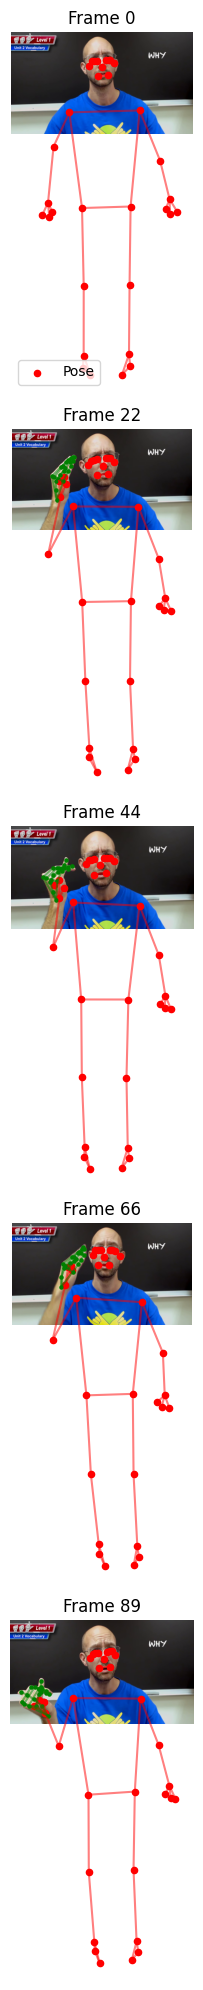

In [6]:
visualize_landmarks_with_video(train_landmarks, list(train_landmarks.keys())[5], train_dir)

In [7]:
# After extracting landmarks in extract_landmarks_from_directory
for filename, landmarks_list in train_landmarks.items():
    if landmarks_list:
        print(f"{filename}: {np.array(landmarks_list).shape}")
        break  # Check one sample

# Similarly for test_landmarks
for filename, landmarks_list in test_landmarks.items():
    if landmarks_list:
        print(f"{filename}: {np.array(landmarks_list).shape}")
        break

# Save train landmarks
with open('train_landmarks.pkl', 'wb') as f:
    pickle.dump(train_landmarks, f)

# Save test landmarks
with open('test_landmarks.pkl', 'wb') as f:
    pickle.dump(test_landmarks, f)

you_5_105_8_709.mp4: (108, 225)
why_63285.mp4: (96, 225)
